# Exploratory data analysis

In this project, we build an end-to-end machine learning pipeline to predict total number of units sold by store `WI_2` one day ahead, given historical daily data for store `WI_2`. This exploratory data analysis will aid in data understanding, thus informing the construction of the end-to-end machine learning pipeline, in particular the data preparation steps prior to model training.

We begin with preliminary data exploration, followed by univariate data analysis and bivariate data analysis, which focuses on relationships between features and future sales. Time-series-specific checks are included where they inform data quality and temporal alignment.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid')


## 1. Preliminary data exploration


Inspect the first few rows to get an intuition for the data.


In [2]:
# configure the project and data paths
candidate_roots = [Path.cwd(), Path.cwd() / 'ts', Path.cwd().parent]
PROJECT_ROOT = next(
    root for root in candidate_roots
    if (root / 'data' / 'm5-forecasting-accuracy').exists()
)
DATA_DIR = PROJECT_ROOT / 'data' / 'm5-forecasting-accuracy'
STORE_ID = 'WI_2'

# load the calendar data
categorical_calendar_columns = [
    'weekday',
    'event_name_1',
    'event_type_1',
    'event_name_2',
    'event_type_2',
]
calendar_raw = pd.read_csv(
    DATA_DIR / 'calendar.csv',
    dtype={column: str for column in categorical_calendar_columns},
    keep_default_na=True,
    na_values=['NA', ''],)

# inspect the first few rows
calendar_raw.head()


,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,NaN,NaN,NaN,NaN,1,0,1


In [3]:
# load the sales data
sales_header = pd.read_csv(DATA_DIR / 'sales_train_evaluation.csv', nrows=0)
day_columns = [column for column in sales_header.columns if column.startswith('d_')]
identifier_columns = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
sales_dtypes = {column: 'string' for column in identifier_columns}
sales_dtypes.update({column: 'int64' for column in day_columns})

sales_raw = pd.read_csv(
    DATA_DIR / 'sales_train_evaluation.csv',
    usecols=identifier_columns + day_columns,
    dtype=sales_dtypes,
    low_memory=False,
)

# inspect the first few rows
sales_raw.head()


,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,d_45,...,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913,d_1914,d_1915,d_1916,d_1917,d_1918,d_1919,d_1920,d_1921,d_1922,d_1923,d_1924,d_1925,d_1926,d_1927,d_1928,d_1929,d_1930,d_1931,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,4,2,3,0,1,2,0,0,0,1,1,3,0,1,1,1,3,0,1,1,0,0,0,2,0,3,5,0,0,1,1,0,2,1,2,2,1,0,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0,1,2,2,1,2,1,1,1,0,1,1,1,0,0,1,1,0,2,1,0,0,0,0,2,1,3,0,0,1,0,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,2,0,1,0,0,...,2,1,3,1,0,2,5,4,2,0,3,0,1,0,5,4,1,0,1,3,7,2,0,0,1,2,4,1,6,4,0,0,0,2,2,4,2,1,1,1,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,4,0,1,0,1,0,1,1,2,0,1,1,2,1,1,0,1,1,2,2,2,4,1,0,2,3,1,0,3,2,3,1,1,3,2,3,2,2,2,2,0,0,0,2,1,0,0,2,1,0


In [4]:
# inspect the dimensions and column names
print('Calendar dimensions:', calendar_raw.shape)
print('Calendar column names:', calendar_raw.columns.tolist())
print('Sales dimensions:', sales_raw.shape)
print('Sales column names:', sales_raw.columns.tolist())


Calendar dimensions: (1969, 13)
Calendar column names: ['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']
Sales dimensions: (30490, 1946)
Sales column names: ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9', 'd_10', 'd_11', 'd_12', 'd_13', 'd_14', 'd_15', 'd_16', 'd_17', 'd_18', 'd_19', 'd_20', 'd_21', 'd_22', 'd_23', 'd_24', 'd_25', 'd_26', 'd_27', 'd_28', 'd_29', 'd_30', 'd_31', 'd_32', 'd_33', 'd_34', 'd_35', 'd_36', 'd_37', 'd_38', 'd_39', 'd_40', 'd_41', 'd_42', 'd_43', 'd_44', 'd_45', 'd_46', 'd_47', 'd_48', 'd_49', 'd_50', 'd_51', 'd_52', 'd_53', 'd_54', 'd_55', 'd_56', 'd_57', 'd_58', 'd_59', 'd_60', 'd_61', 'd_62', 'd_63', 'd_64', 'd_65', 'd_66', 'd_67', 'd_68', 'd_69', 'd_70', 'd_71', 'd_72', 'd_73', 'd_74', 'd_75', 'd_76', 'd_77', 'd_78', 'd_79', 'd_80', 'd_81', 'd_82', 'd_83', 'd_84', 'd_85', 'd_86', 'd_

In [5]:
# validate the raw data against data quality rules
expected_day_columns = [f'd_{number}' for number in range(1, len(day_columns) + 1)]
raw_dates = pd.to_datetime(calendar_raw['date'], errors='coerce')
calendar_date_range = pd.date_range(
    raw_dates.min(),
    raw_dates.max(),
    freq='D',
)
event_1_fields_are_paired = calendar_raw['event_name_1'].isna().eq(
    calendar_raw['event_type_1'].isna()
).all()
event_2_fields_are_paired = calendar_raw['event_name_2'].isna().eq(
    calendar_raw['event_type_2'].isna()
).all()

raw_validation = pd.Series({
    'calendar_has_d_column': 'd' in calendar_raw.columns,
    'calendar_dates_parseable': raw_dates.notna().all(),
    'calendar_dates_unique': raw_dates.is_unique,
    'calendar_dates_sorted': raw_dates.is_monotonic_increasing,
    'calendar_daily_coverage': len(
        calendar_date_range.difference(raw_dates)
    ) == 0,
    'sales_day_columns_in_sequence': day_columns == expected_day_columns,
    'calendar_covers_sales_days': len(calendar_raw) >= len(day_columns),
    'sales_nonnegative': (sales_raw[day_columns] >= 0).all().all(),
    'sales_item_store_unique': ~sales_raw.duplicated(
        ['item_id', 'store_id']
    ).any(),
    'event_1_name_type_are_paired': event_1_fields_are_paired,
    'event_2_name_type_are_paired': event_2_fields_are_paired,
})
raw_validation.to_frame('passes')


,passes
calendar_has_d_column,False
calendar_dates_parseable,True
calendar_dates_unique,True
calendar_dates_sorted,True
calendar_daily_coverage,True
sales_day_columns_in_sequence,True
calendar_covers_sales_days,True
sales_nonnegative,True
sales_item_store_unique,True
event_1_name_type_are_paired,True



The calendar contains 1,969 rows and 13 columns.
The sales contain 30,490 item-store rows with 1,941 historical day columns. The calendar runs from 2011-01-29 to 2016-06-19. The selected store is WI_2.
The calendar has 28 more dates than the sales history because it includes the future dates used for the forecasting horizon. The M5 day key d maps each chronological calendar date to a sales column such as d_1 or d_1941.


### 1.1 Preliminary data exploration by columns

The columns are categorised as follows.


In [6]:
# assign columns to categories
identifiers = ['d', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
numeric_integer_features = ['snap_CA', 'snap_TX', 'snap_WI']
numeric_float_features = []
categorical_nominal_features = [
    'weekday',
    'event_name_1',
    'event_type_1',
    'event_name_2',
    'event_type_2',
]
datetime_features = ['date', 'wm_yr_wk', 'wday', 'month', 'year']
calendar_features = ['wm_yr_wk', 'wday', 'month', 'year']
target = ['sales']

category_to_column_dict = {
    'identifier': identifiers,
    'numeric_integer': numeric_integer_features,
    'numeric_float': numeric_float_features,
    'categorical_nominal': categorical_nominal_features,
    'datetime': datetime_features,
    'target': target,
}
category_to_column_dict


{'identifier': ['d', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
 'numeric_integer': ['snap_CA', 'snap_TX', 'snap_WI'],
 'numeric_float': [],
 'categorical_nominal': ['weekday',
  'event_name_1',
  'event_type_1',
  'event_name_2',
  'event_type_2'],
 'datetime': ['date', 'wm_yr_wk', 'wday', 'month', 'year'],
 'target': ['sales']}

Information regarding each column is summarised below.


In [7]:
# create a dictionary to map categories to columns
column_to_category_dict = {
    column: category
    for category, columns in category_to_column_dict.items()
    for column in columns
}
# create a columns summary
columns_summary = pd.DataFrame({
    'column': calendar_raw.columns,
    'category': [
        column_to_category_dict.get(column, 'uncategorized')
        for column in calendar_raw.columns
    ],
    'dtype': calendar_raw.dtypes.astype(str).values,
    'null_count': calendar_raw.isna().sum().values,
})
columns_summary.sort_values('category')


,column,category,dtype,null_count
2,weekday,categorical_nominal,str,0
6,event_name_1,categorical_nominal,str,1807
7,event_type_1,categorical_nominal,str,1807
8,event_name_2,categorical_nominal,str,1964
9,event_type_2,categorical_nominal,str,1964
0,date,datetime,str,0
1,wm_yr_wk,datetime,int64,0
3,wday,datetime,int64,0
4,month,datetime,int64,0
5,year,datetime,int64,0


In [8]:
# inspect the raw data types
raw_type_validation = pd.Series({
    'categorical_nominal_are_strings': all(
        calendar_raw[column].dropna().map(type).eq(str).all()
        for column in categorical_nominal_features
    ),
    'date_is_string': calendar_raw['date'].dropna().map(type).eq(str).all(),
    'numeric_integer_is_int64': all(
        calendar_raw[column].dtype == 'int64'
        for column in numeric_integer_features
    ),
    'calendar_fields_are_int64': all(
        calendar_raw[column].dtype == 'int64'
        for column in calendar_features
    ),
})
raw_type_validation


categorical_nominal_are_strings    True
date_is_string                     True
numeric_integer_is_int64           True
calendar_fields_are_int64          True
dtype: bool

Inspecting the columns summary informs the following decisions:

Correcting structural errors: the calendar file is missing the canonical d identifier expected by the M5 format. The dates are available and can be validated before deriving d from row order.

Handling datetime values: the time axis is represented by one sorted date column with datetime type. The `wm_yr_wk`, `wday`, `month`, and `year` fields are included as datetime features.

Handling event values:

The event name and event type fields are null together when no event is recorded. These expected categorical nulls will be represented as No event during cleaning.


In [9]:
# convert the calendar date to datetime
def convert_calendar_date_to_datetime(calendar):
    """Return a copy with date converted to datetime."""
    calendar = calendar.copy()
    calendar['date'] = pd.to_datetime(calendar['date'], errors='coerce')
    return calendar

calendar = convert_calendar_date_to_datetime(calendar_raw)

# enforce the cleaned data types
type_validation = pd.Series({
    'categorical_nominal_are_strings': all(
        calendar[column].dropna().map(type).eq(str).all()
        for column in categorical_nominal_features
    ),
    'date_is_datetime': pd.api.types.is_datetime64_dtype(
        calendar['date']
    ),
    'numeric_integer_is_int64': all(
        calendar[column].dtype == 'int64'
        for column in numeric_integer_features
    ),
    'calendar_fields_are_int64': all(
        calendar[column].dtype == 'int64'
        for column in calendar_features
    ),
})
assert type_validation.all(), 'Cleaned column types do not meet the expected rules.'
type_validation


categorical_nominal_are_strings    True
date_is_datetime                   True
numeric_integer_is_int64           True
calendar_fields_are_int64          True
dtype: bool

In [10]:
# verify the datetime conversion
calendar['date'].dtype


dtype('<M8[us]')

In [11]:
# validate chronological order and daily coverage
calendar_range = pd.date_range(
    calendar['date'].min(),
    calendar['date'].max(),
    freq='D',
)
calendar_validation = pd.Series({
    'date_parseable': calendar['date'].notna().all(),
    'date_unique': calendar['date'].is_unique,
    'date_sorted': calendar['date'].is_monotonic_increasing,
    'missing_calendar_dates': len(
        calendar_range.difference(calendar['date'])
    ),
})
calendar_validation.to_frame('value')
assert calendar_validation['date_parseable']
assert calendar_validation['date_unique']
assert calendar_validation['date_sorted']
assert calendar_validation['missing_calendar_dates'] == 0


In [12]:
# inspect missing values
missingness = pd.DataFrame({
    'missing_count': calendar_raw.isna().sum(),
})
missingness['missing_pct'] = (
    missingness['missing_count'] / len(calendar_raw) * 100
).round(2)
missingness.sort_values('missing_count', ascending=False)


,missing_count,missing_pct
event_name_2,1964,99.75
event_type_2,1964,99.75
event_name_1,1807,91.77
event_type_1,1807,91.77
date,0,0.00
wm_yr_wk,0,0.00
weekday,0,0.00
wday,0,0.00
month,0,0.00
year,0,0.00


The date column is parseable, unique, sorted, and complete. The main structural issue is the missing d column. Event fields are intentionally sparse: event_name_1 and event_type_1 are missing on 1,807 calendar rows, while event_name_2 and event_type_2 are missing on 1,964 rows.


### 1.2 Preliminary data exploration by rows

Inspect duplicate entries based on the candidate identifiers.


In [13]:
# detect duplicated entries based on candidate identifiers
duplicate_sales_count = sales_raw.duplicated(
    ['item_id', 'store_id']
).sum()
duplicate_calendar_count = calendar['date'].duplicated().sum()

pd.Series({
    'duplicate_item_store_rows': duplicate_sales_count,
    'duplicate_calendar_dates': duplicate_calendar_count,
})


duplicate_item_store_rows    0
duplicate_calendar_dates     0
dtype: int64

In [14]:
# show examples of duplicated entries
duplicate_sales_rows = sales_raw.loc[
    sales_raw.duplicated(['item_id', 'store_id'], keep=False)
]
duplicate_sales_rows.head()


,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,d_45,...,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913,d_1914,d_1915,d_1916,d_1917,d_1918,d_1919,d_1920,d_1921,d_1922,d_1923,d_1924,d_1925,d_1926,d_1927,d_1928,d_1929,d_1930,d_1931,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941


In [15]:
# validate row counts and day-column order
row_validation = pd.Series({
    'number_of_stores': sales_raw['store_id'].nunique(),
    'number_of_states': sales_raw['state_id'].nunique(),
    'rows_for_selected_store': int(
        (sales_raw['store_id'] == STORE_ID).sum()
    ),
    'day_columns_contiguous': day_columns == [
        f'd_{number}' for number in range(1, len(day_columns) + 1)
    ],
})
row_validation.to_frame('value')


,value
number_of_stores,10
number_of_states,3
rows_for_selected_store,3049
day_columns_contiguous,True


Inspecting the rows informs the following decisions:

Removing duplicate entries: there are no duplicate item-store rows and no duplicate calendar dates, so no duplicate rows are removed.

Validating chronological order: the calendar dates are sorted and complete. We can derive d from this validated order and align the store's daily sales to the calendar.


In [16]:
# derive the missing calendar day key from validated row order
calendar.insert(
    0,
    'd',
    [f'd_{number}' for number in range(1, len(calendar) + 1)],
)

# aggregate item-level sales to one daily total for the selected store
store_sales = sales_raw.loc[sales_raw['store_id'] == STORE_ID]
daily_sales = store_sales[day_columns].sum(axis=0).rename('sales')
daily_sales = daily_sales.rename_axis('d').reset_index()

# create a daily time series with a datetime index
df = daily_sales.merge(
    calendar,
    on='d',
    how='left',
    validate='one_to_one',
).sort_values('date').set_index('date')
df.index.name = 'datetime'

df.head()


,d,sales,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
datetime,,,,,,,,,,,,,,
2011-01-29,d_1,2256,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2011-01-30,d_2,1922,11101,Sunday,2,1,2011,NaN,NaN,NaN,NaN,0,0,0
2011-01-31,d_3,2018,11101,Monday,3,1,2011,NaN,NaN,NaN,NaN,0,0,0
2011-02-01,d_4,2522,11101,Tuesday,4,2,2011,NaN,NaN,NaN,NaN,1,1,0
2011-02-02,d_5,1175,11101,Wednesday,5,2,2011,NaN,NaN,NaN,NaN,1,0,1


In [17]:
# validate the aggregated time series
expected_dates = pd.date_range(df.index.min(), df.index.max(), freq='D')
expected_wday = (df.index.dayofweek + 2) % 7 + 1

time_series_validation = pd.Series({
    'daily_rows': len(df),
    'date_unique': df.index.is_unique,
    'date_sorted': df.index.is_monotonic_increasing,
    'daily_frequency': pd.infer_freq(df.index) == 'D',
    'missing_sales_dates': len(expected_dates.difference(df.index)),
    'd_matches_sales_columns': set(df['d']) == set(day_columns),
    'sales_nonnegative': (df['sales'] >= 0).all(),
    'sales_integer_like': np.isclose(df['sales'] % 1, 0).all(),
    'wday_matches_date': df['wday'].eq(expected_wday).all(),
    'month_matches_date': df['month'].eq(df.index.month).all(),
    'year_matches_date': df['year'].eq(df.index.year).all(),
})
time_series_validation.to_frame('passed')
assert time_series_validation['date_unique']
assert time_series_validation['date_sorted']
assert time_series_validation['daily_frequency']
assert time_series_validation['missing_sales_dates'] == 0
assert time_series_validation['d_matches_sales_columns']
assert time_series_validation['sales_nonnegative']
assert time_series_validation['sales_integer_like']
assert time_series_validation['wday_matches_date']
assert time_series_validation['month_matches_date']
assert time_series_validation['year_matches_date']


The aggregated WI_2 table contains 1,941 daily observations. Every temporal validation check passes: the index is unique, sorted, complete, and daily; the d keys align with the sales columns; and the calendar fields match the date. Sales are nonnegative and integer-like.


In [18]:
# clean missing event labels without changing sales values
def fill_missing_event_labels(frame, event_columns):
    """Return a copy with missing event labels represented explicitly."""
    frame = frame.copy()
    for column in event_columns:
        frame[column] = frame[column].fillna('No event')
    frame['has_event'] = (
        frame['event_name_1'] != 'No event'
    ).astype(int)
    return frame

event_columns = [
    'event_name_1',
    'event_type_1',
    'event_name_2',
    'event_type_2',
]
clean_df = fill_missing_event_labels(df, event_columns)

cleaning_validation = pd.Series({
    'remaining_missing_sales': clean_df['sales'].isna().sum(),
    'remaining_missing_event_labels': clean_df[event_columns].isna().sum().sum(),
})
cleaning_validation.to_frame('value')
assert cleaning_validation['remaining_missing_sales'] == 0
assert cleaning_validation['remaining_missing_event_labels'] == 0


## 2. Univariate data analysis


### 2.1 Univariate data analysis for numeric features + numeric target variable

Inspecting summary statistics for the numeric target variable.


In [19]:
# inspect summary statistics for daily sales
sales_summary = clean_df['sales'].describe().to_frame('sales')
sales_summary.loc['zero_days'] = (clean_df['sales'] == 0).sum()
sales_summary.loc['negative_days'] = (clean_df['sales'] < 0).sum()
sales_summary.loc['missing_days'] = clean_df['sales'].isna().sum()
sales_summary


,sales
count,1941.000000
mean,3450.792375
std,1304.984661
min,0.000000
25%,2376.000000
50%,3522.000000
75%,4403.000000
max,7852.000000
zero_days,2.000000
negative_days,0.000000


Inspecting the distribution, boxplot, and rolling summaries of daily sales.


/var/folders/z5/t6prsb910p5cn4_p8358dl280000gq/T/ipykernel_77976/2056996989.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(clean_df['sales'].dropna(), vert=False)


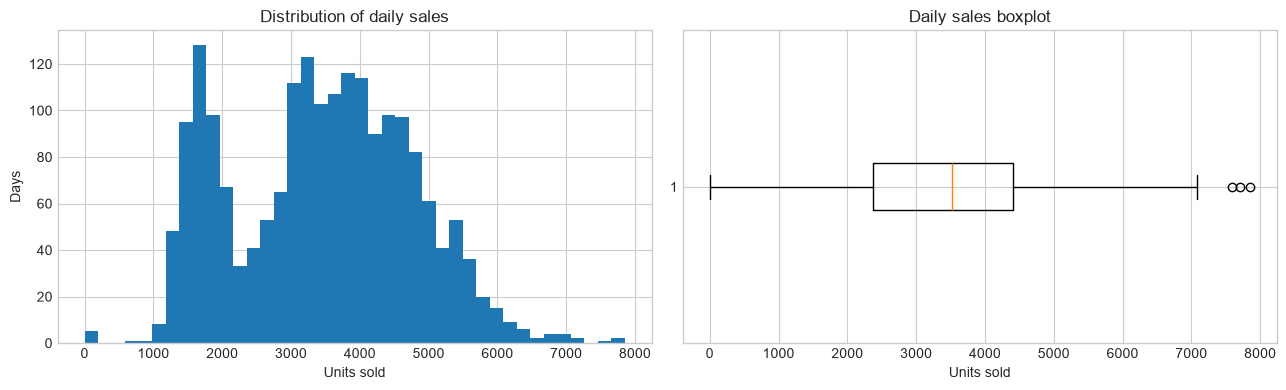

In [20]:
# plot the sales distribution and boxplot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
clean_df['sales'].plot(
    kind='hist',
    bins=40,
    ax=axes[0],
    title='Distribution of daily sales',
)
axes[0].set_xlabel('Units sold')
axes[0].set_ylabel('Days')
axes[1].boxplot(clean_df['sales'].dropna(), vert=False)
axes[1].set_title('Daily sales boxplot')
axes[1].set_xlabel('Units sold')
plt.tight_layout()
plt.show()


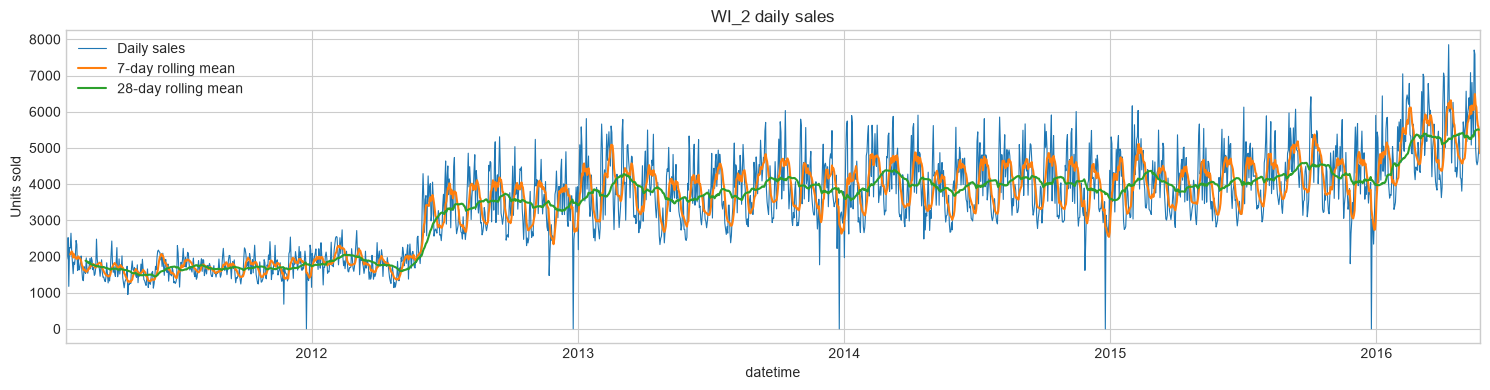

In [21]:
# plot daily sales and rolling summaries
fig, ax = plt.subplots(figsize=(15, 4))
clean_df['sales'].plot(ax=ax, label='Daily sales', linewidth=0.8)
clean_df['sales'].rolling(7).mean().plot(
    ax=ax,
    label='7-day rolling mean',
)
clean_df['sales'].rolling(28).mean().plot(
    ax=ax,
    label='28-day rolling mean',
)
ax.set_title(f'{STORE_ID} daily sales')
ax.set_ylabel('Units sold')
ax.legend()
plt.tight_layout()
plt.show()


The daily sales mean is 3,450.79 units and the standard deviation is 1,304.98. Sales range from 0 to 7,852 units. There are two zero-sales days, no negative day, and no missing sales day.

The IQR upper cutoff is 7,444 units, producing three high-sales days. These observations are retained for review because a genuine demand peak may be important to forecast.


In [22]:
# identify high-sales days using the IQR rule
q1, q3 = clean_df['sales'].quantile([0.25, 0.75])
upper_outlier_cutoff = q3 + 1.5 * (q3 - q1)
outlier_days = clean_df.loc[
    clean_df['sales'] > upper_outlier_cutoff,
    ['d', 'sales', 'weekday', 'event_name_1'],
]
print(f'IQR upper cutoff: {upper_outlier_cutoff:,.0f}')
print(f'Number of IQR high days: {len(outlier_days)}')
outlier_days.sort_values('sales', ascending=False).head(10)


IQR upper cutoff: 7,444
Number of IQR high days: 3


,d,sales,weekday,event_name_1
datetime,,,,
2016-04-09,d_1898,7852,Saturday,No event
2016-05-14,d_1933,7704,Saturday,No event
2016-05-15,d_1934,7586,Sunday,No event


### Inspecting low-sales days

Low daily sales are reviewed against the calendar and the number of item rows with nonzero sales before deciding whether they are data-quality issues.


In [23]:
# identify low-sales days using the IQR rule
lower_outlier_cutoff = q1 - 1.5 * (q3 - q1)
low_sales_days = clean_df.loc[
    clean_df['sales'] < lower_outlier_cutoff,
].copy()
low_sales_review = clean_df.nsmallest(10, 'sales').copy()
low_sales_review['date'] = low_sales_review.index
low_sales_review['nonzero_item_rows'] = low_sales_review['d'].map(
    lambda day: (store_sales[day] > 0).sum()
)
low_sales_review = low_sales_review[
    [
        'date',
        'd',
        'sales',
        'weekday',
        'event_name_1',
        'event_type_1',
        'snap_WI',
        'nonzero_item_rows',
    ]
]
print(f'IQR lower cutoff: {lower_outlier_cutoff:,.0f}')
print(f'Number of IQR low days: {len(low_sales_days)}')
low_sales_review[
    [
        'date',
        'd',
        'sales',
        'weekday',
        'event_name_1',
        'event_type_1',
        'snap_WI',
        'nonzero_item_rows',
    ]
]


IQR lower cutoff: -664
Number of IQR low days: 0


,date,d,sales,weekday,event_name_1,event_type_1,snap_WI,nonzero_item_rows
datetime,,,,,,,,
2013-12-25,2013-12-25,d_1062,0,Wednesday,Christmas,National,0,0
2014-12-25,2014-12-25,d_1427,0,Thursday,Christmas,National,0,0
2015-12-25,2015-12-25,d_1792,1,Friday,Christmas,National,0,1
2011-12-25,2011-12-25,d_331,3,Sunday,Christmas,National,0,3
2012-12-25,2012-12-25,d_697,3,Tuesday,Christmas,National,0,3
2011-11-24,2011-11-24,d_300,682,Thursday,Thanksgiving,National,0,239
2011-04-24,2011-04-24,d_86,949,Sunday,OrthodoxEaster,Religious,0,327
2011-05-29,2011-05-29,d_121,1126,Sunday,No event,No event,0,387
2011-04-19,2011-04-19,d_81,1135,Tuesday,No event,No event,0,390


The lower IQR cutoff is -664 units, so no days meet the formal lower-outlier rule. The lowest five days occur on Christmas Day from 2011 to 2015 and contain 0, 0, 1, 3, and 3 units. These values are consistent with a store-closure pattern recorded by the Christmas national event. The remaining low values are historical demand observations, so the low-sales days are retained rather than imputed or removed.


### Inspecting the bimodal sales pattern

The sales distribution is compared across the early period and the higher-sales period to determine whether the second mode is associated with a change in item coverage.


In [24]:
# compare sales levels before and after the transition
transition_summary = clean_df[['sales', 'd']].copy()
transition_summary['nonzero_item_rows'] = transition_summary['d'].map(
    lambda day: (store_sales[day] > 0).sum()
)
transition_summary['period'] = pd.cut(
    transition_summary.index,
    [
        pd.Timestamp('2010-01-01'),
        pd.Timestamp('2012-01-01'),
        pd.Timestamp('2012-06-01'),
        pd.Timestamp('2016-07-01'),
    ],
    labels=['Before 2012', 'Jan-May 2012', 'From Jun 2012'],
)
transition_summary.groupby('period', observed=False)[
    ['sales', 'nonzero_item_rows']
].agg(['count', 'mean', 'median', 'min', 'max']).round(2)


sales                              nonzero_item_rows           \
              count     mean  median   min   max             count     mean   
period                                                                        
Before 2012     338  1678.70  1651.5     3  2643               338   463.57   
Jan-May 2012    152  1884.02  1857.5  1140  3551               152   543.44   
From Jun 2012  1451  4027.72  3938.0     0  7852              1451  1039.10   

                                  
               median  min   max  
period                            
Before 2012     465.0    3   581  
Jan-May 2012    531.0  406   855  
From Jun 2012  1034.0    0  1585

The sales distribution is bimodal because the `WI_2` series combines an early low-coverage period with a later higher-coverage period. Before 2012, mean daily sales are 1,678.70 units with about 464 nonzero item rows per day. From June 2012 onward, mean daily sales increase to 4,027.72 units with about 1,039 nonzero item rows per day. A large number of item rows first record nonzero sales around the transition, which is consistent with an expansion of the store's active assortment or sales coverage. The exact operational cause cannot be confirmed from the sales and calendar files alone, so the pre-change observations are excluded from downstream feature engineering and modeling.


### 2.2 Univariate data analysis for categorical features

Inspecting the unique values and frequencies of the calendar and event features.


In [25]:
# inspect unique values for categorical features
categorical_features = [
    'weekday',
    'event_name_1',
    'event_type_1',
    'snap_WI',
]
for column in categorical_features:
    print(column, ':')
    display(clean_df[column].value_counts(dropna=False).head(15))


weekday :


weekday
Saturday     278
Sunday       278
Monday       277
Tuesday      277
Wednesday    277
Thursday     277
Friday       277
Name: count, dtype: int64

event_name_1 :


event_name_1
No event          1783
SuperBowl            6
ValentinesDay        6
PresidentsDay        6
LentStart            6
LentWeek2            6
StPatricksDay        6
Purim End            6
Pesach End           6
Mother's day         6
OrthodoxEaster       5
Cinco De Mayo        5
MemorialDay          5
NBAFinalsStart       5
NBAFinalsEnd         5
Name: count, dtype: int64

event_type_1 :


event_type_1
No event     1783
Religious      54
National       51
Cultural       37
Sporting       16
Name: count, dtype: int64

snap_WI :


snap_WI
0    1301
1     640
Name: count, dtype: int64

The weekday and SNAP fields contain consistent categorical levels. Event fields are sparse because most days have no recorded event; these missing values have been changed to No event rather than dropping the rows.


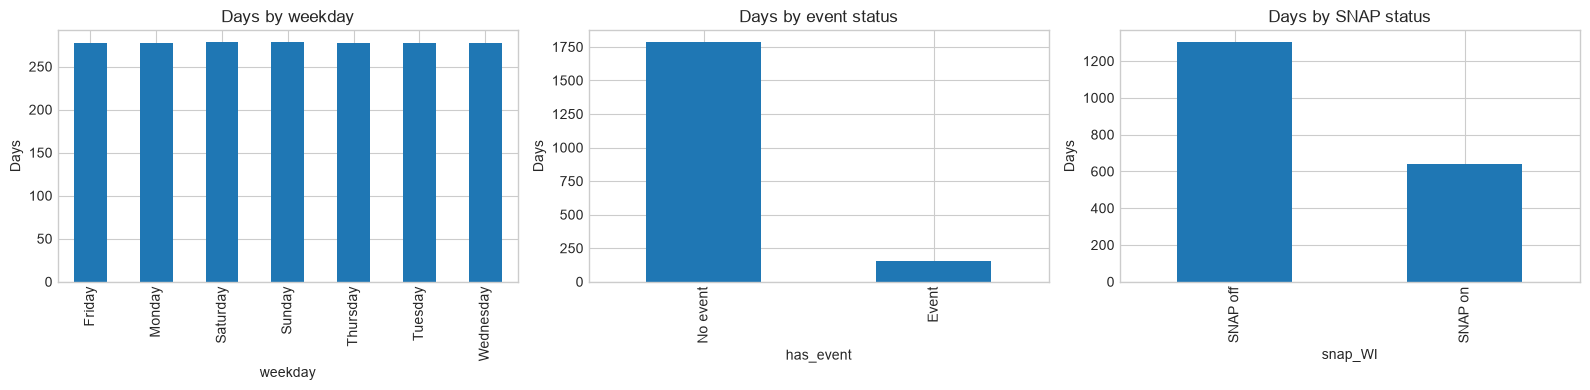

In [26]:
# plot counts for categorical features
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
clean_df['weekday'].value_counts().sort_index().plot(
    kind='bar',
    ax=axes[0],
    title='Days by weekday',
)
clean_df['has_event'].value_counts().rename(
    index={0: 'No event', 1: 'Event'}
).plot(
    kind='bar',
    ax=axes[1],
    title='Days by event status',
)
clean_df['snap_WI'].value_counts().rename(
    index={0: 'SNAP off', 1: 'SNAP on'}
).plot(
    kind='bar',
    ax=axes[2],
    title='Days by SNAP status',
)
for axis in axes:
    axis.set_ylabel('Days')
plt.tight_layout()
plt.show()


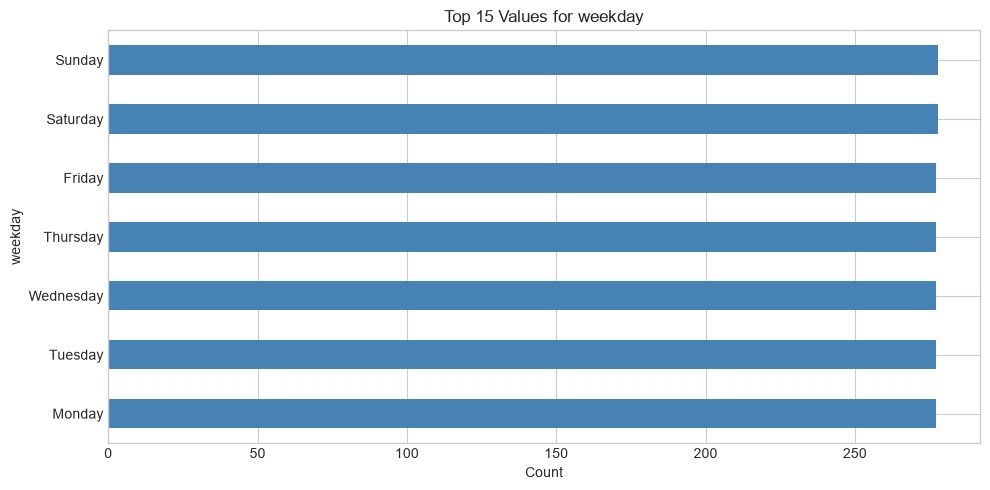

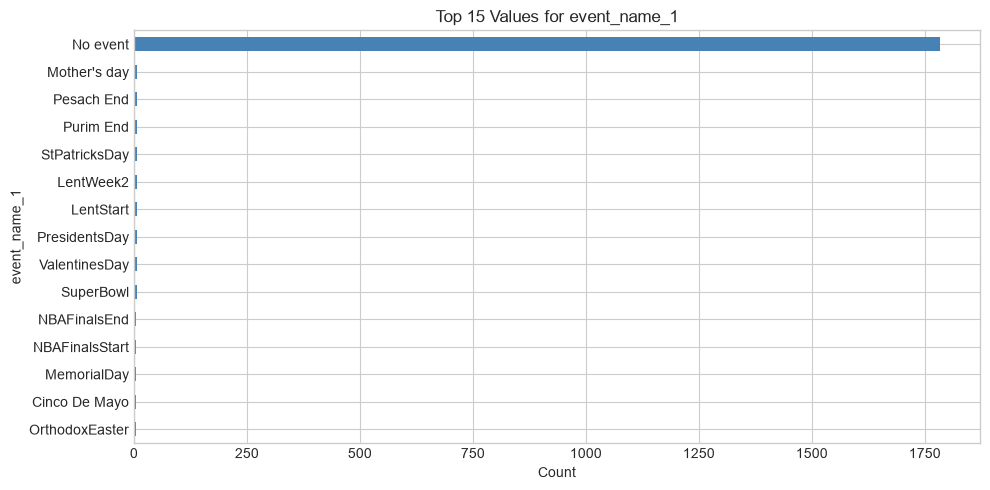

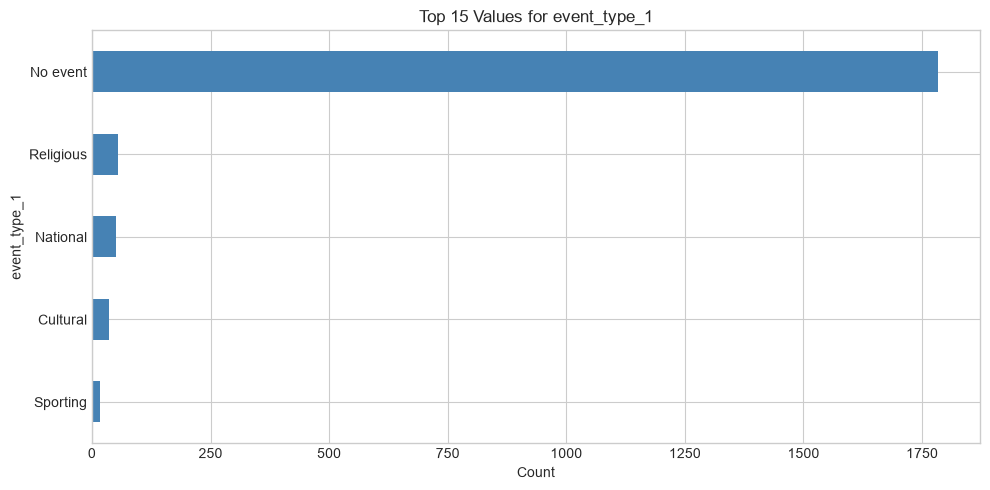

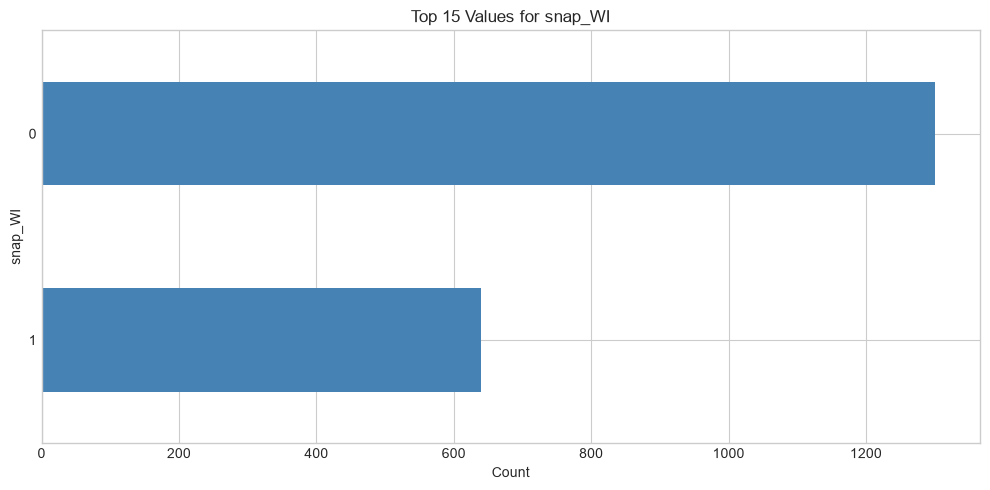

In [27]:
# Bar plots for categorical features
import matplotlib.pyplot as plt

for column in categorical_features:
    counts = clean_df[column].value_counts(dropna=False).head(15)
    counts.index = counts.index.map(
        lambda value: "Missing" if pd.isna(value) else str(value)
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    counts.sort_values().plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"Top 15 Values for {column}")
    ax.set_xlabel("Count")
    ax.set_ylabel(column)
    plt.tight_layout()
    plt.show()


## 3. Bivariate data analysis

We compare daily sales with calendar variables and previous observations. These are descriptive comparisons and do not establish causal effects.


In [28]:
# compare sales across calendar and event groups
weekday_summary = clean_df.groupby(
    ['wday', 'weekday'],
    observed=True,
)['sales'].agg(['count', 'mean', 'median', 'sum']).round(2)

month_summary = clean_df.groupby(
    'month',
    observed=True,
)['sales'].agg(['count', 'mean', 'median', 'sum']).round(2)

event_summary = clean_df.groupby(
    'has_event',
    observed=True,
)['sales'].agg(['count', 'mean', 'median', 'sum']).round(2)

snap_summary = clean_df.groupby(
    'snap_WI',
    observed=True,
)['sales'].agg(['count', 'mean', 'median', 'sum']).round(2)

display(weekday_summary)
display(month_summary)
display(event_summary)
snap_summary


,,count,mean,median,sum
wday,weekday,,,,
1,Saturday,278,4006.40,4218.5,1113780
2,Sunday,278,3647.62,3819.0,1014039
3,Monday,277,3262.44,3301.0,903697
4,Tuesday,277,3187.36,3148.0,882900
5,Wednesday,277,3227.51,3277.0,894021
6,Thursday,277,3233.84,3252.0,895773
7,Friday,277,3587.65,3788.0,993778


,count,mean,median,sum
month,,,,
1,158,3557.63,3546.5,562106
2,170,3678.05,3862.5,625269
3,186,3404.72,3453.0,633278
4,180,3384.34,3453.5,609181
5,177,3304.27,3248.0,584855
6,150,3333.47,3391.0,500020
7,155,3381.81,3417.0,524180
8,155,3523.83,3636.0,546193
9,150,3573.59,3699.0,536039


,count,mean,median,sum
has_event,,,,
0,1783,3476.62,3532.0,6198805
1,158,3159.39,3361.0,499183


,count,mean,median,sum
snap_WI,,,,
0,1301,3113.19,3234.0,4050263
1,640,4137.07,4529.5,2647725


Saturday has the highest mean daily sales at 4,006.40 units, while Tuesday has the lowest at 3,187.36. February has the highest monthly mean at 3,678.05 units and May the lowest at 3,304.27.

SNAP-on days average 4,137.07 units compared with 3,113.19 on SNAP-off days. Days with a recorded event average 3,159.39 units compared with 3,476.62 on days without a recorded event. These differences are associations, not causal conclusions.


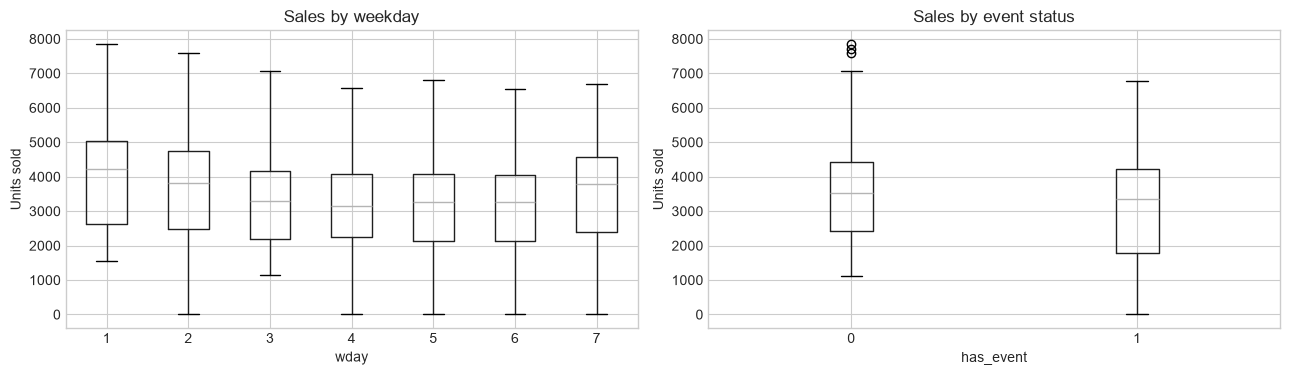

In [29]:
# plot sales by weekday and event status
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
clean_df.boxplot(column='sales', by='wday', ax=axes[0])
axes[0].set_title('Sales by weekday')
axes[0].set_xlabel('wday')
axes[0].set_ylabel('Units sold')
clean_df.boxplot(column='sales', by='has_event', ax=axes[1])
axes[1].set_title('Sales by event status')
axes[1].set_xlabel('has_event')
axes[1].set_ylabel('Units sold')
plt.suptitle('')
plt.tight_layout()
plt.show()


In [30]:
# retain only observations from the later sales regime
regime_change_date = pd.Timestamp('2012-06-01')
clean_df = clean_df.loc[clean_df.index >= regime_change_date].copy()

# remove redundant datetime fields after descriptive analysis
datetime_columns = calendar_features + ['weekday']
clean_df = clean_df.drop(columns=datetime_columns)
clean_df.head()


,d,sales,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,has_event
datetime,,,,,,,,,,
2012-06-01,d_490,3551,No event,No event,No event,No event,1,1,0,0
2012-06-02,d_491,4289,No event,No event,No event,No event,1,0,1,0
2012-06-03,d_492,3629,No event,No event,No event,No event,1,1,1,0
2012-06-04,d_493,2664,No event,No event,No event,No event,1,0,0,0
2012-06-05,d_494,3578,No event,No event,No event,No event,1,1,1,0


### Descriptive time-series analysis

The time-series is examined through trend, weekly seasonality, rolling statistics, and dependence. An additive decomposition is used because the sales series contains a zero value.


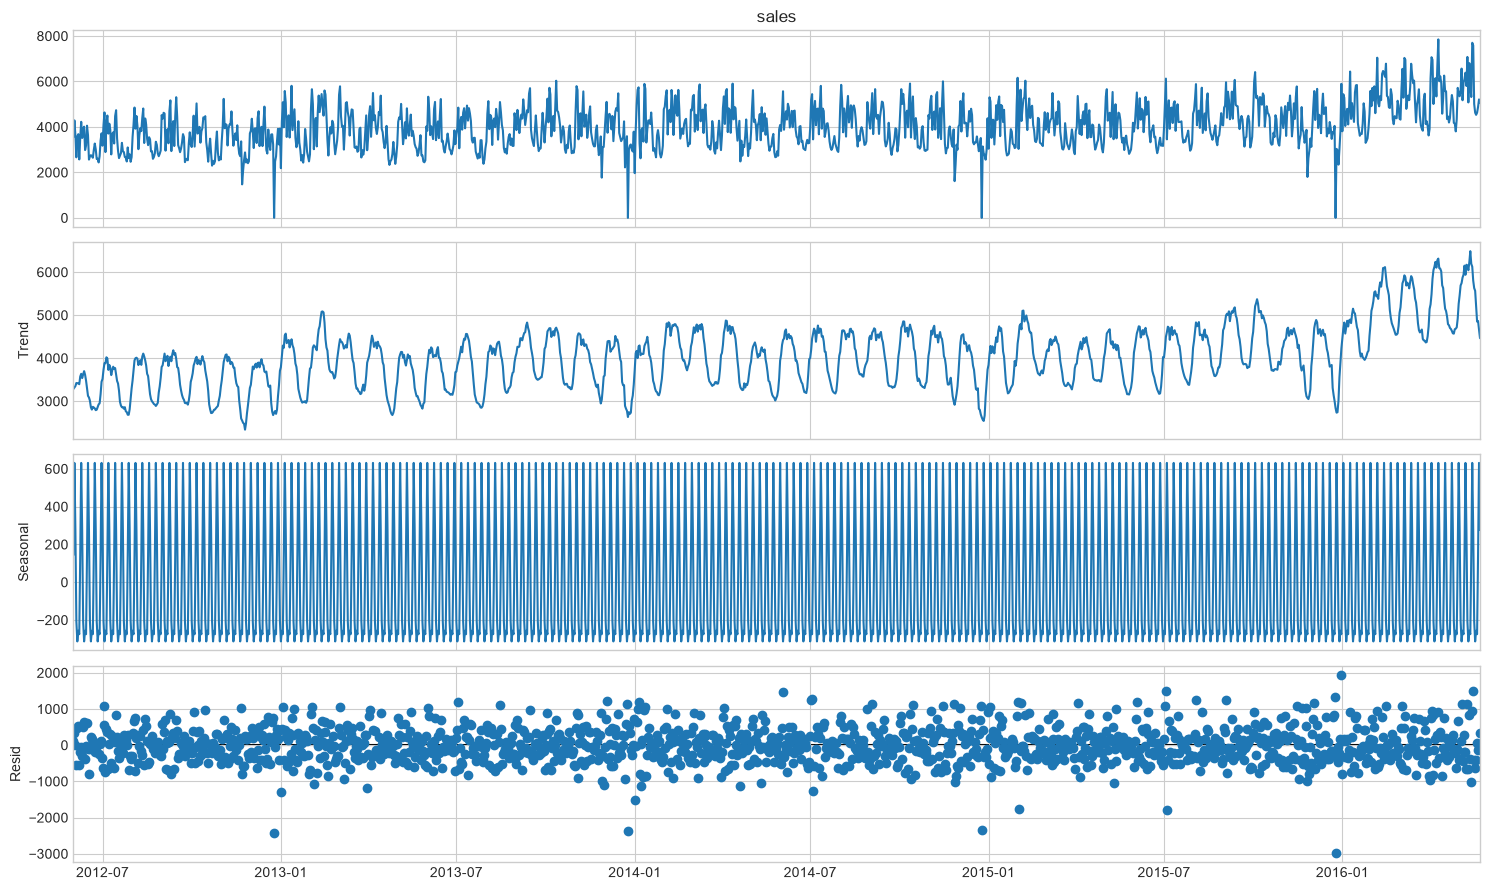

,rolling_mean_28,rolling_std_28
datetime,,
2012-06-01,NaN,NaN
2012-11-28,3396.142857,834.807883
2013-05-27,3639.785714,658.911187
2013-11-23,3986.892857,840.882047
2014-05-22,3890.321429,680.006648
2014-11-18,4076.142857,933.065387
2015-05-17,4035.714286,781.156733
2015-11-13,4155.321429,654.034661
2016-05-11,5326.750000,870.909130


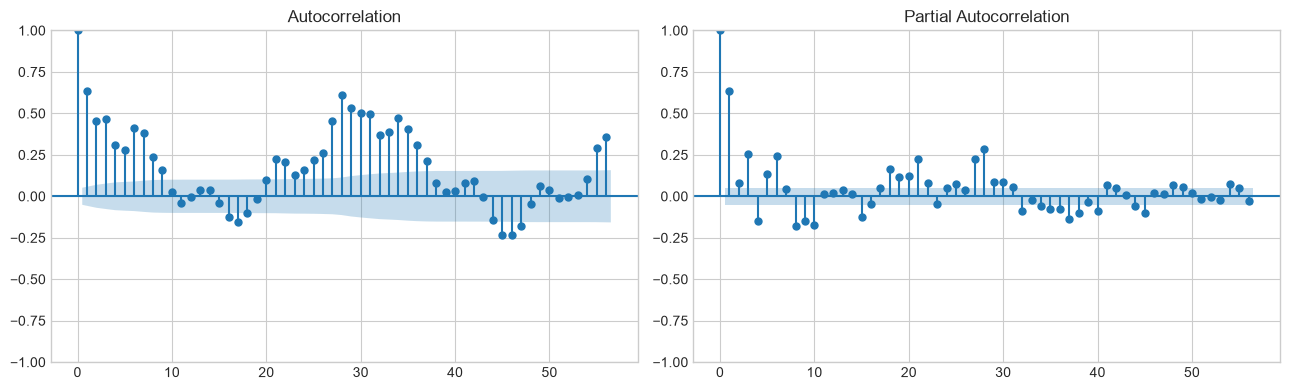

In [31]:
# run time-series decomposition and dependence diagnostics
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

series = clean_df['sales'].astype(float).asfreq('D')
decomposition = seasonal_decompose(
    series,
    model='additive',
    period=7,
    extrapolate_trend='period',
)
figure = decomposition.plot()
figure.set_size_inches(15, 9)
plt.tight_layout()
plt.show()

rolling_statistics = pd.DataFrame({
    'rolling_mean_28': series.rolling(28).mean(),
    'rolling_std_28': series.rolling(28).std(),
})
display(rolling_statistics.iloc[::180].head(12))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(series, lags=56, ax=axes[0])
plot_pacf(series, lags=56, ax=axes[1], method='ywm')
plt.tight_layout()
plt.show()


The decomposition and rolling statistics show a changing level over time with weekly dependence. The ACF and PACF plots provide evidence that earlier sales values are related to current sales, so lag and seasonal features are appropriate candidates.


### Comparing decomposition periods

The daily series is decomposed with weekly, monthly, quarterly, and yearly periods. The monthly, quarterly, and yearly periods are represented by 30, 90, and 365 days because seasonal decomposition requires a fixed integer period. Each plot uses a different display window: the latest 12 weeks, 12 months, 8 quarters, and the full yearly history.


,period,period_days,seasonal_std,residual_std
0,weekly,7,333.72,479.23
1,monthly,30,225.04,783.80
2,quarterly,90,244.19,795.99
3,yearly,365,735.63,475.00


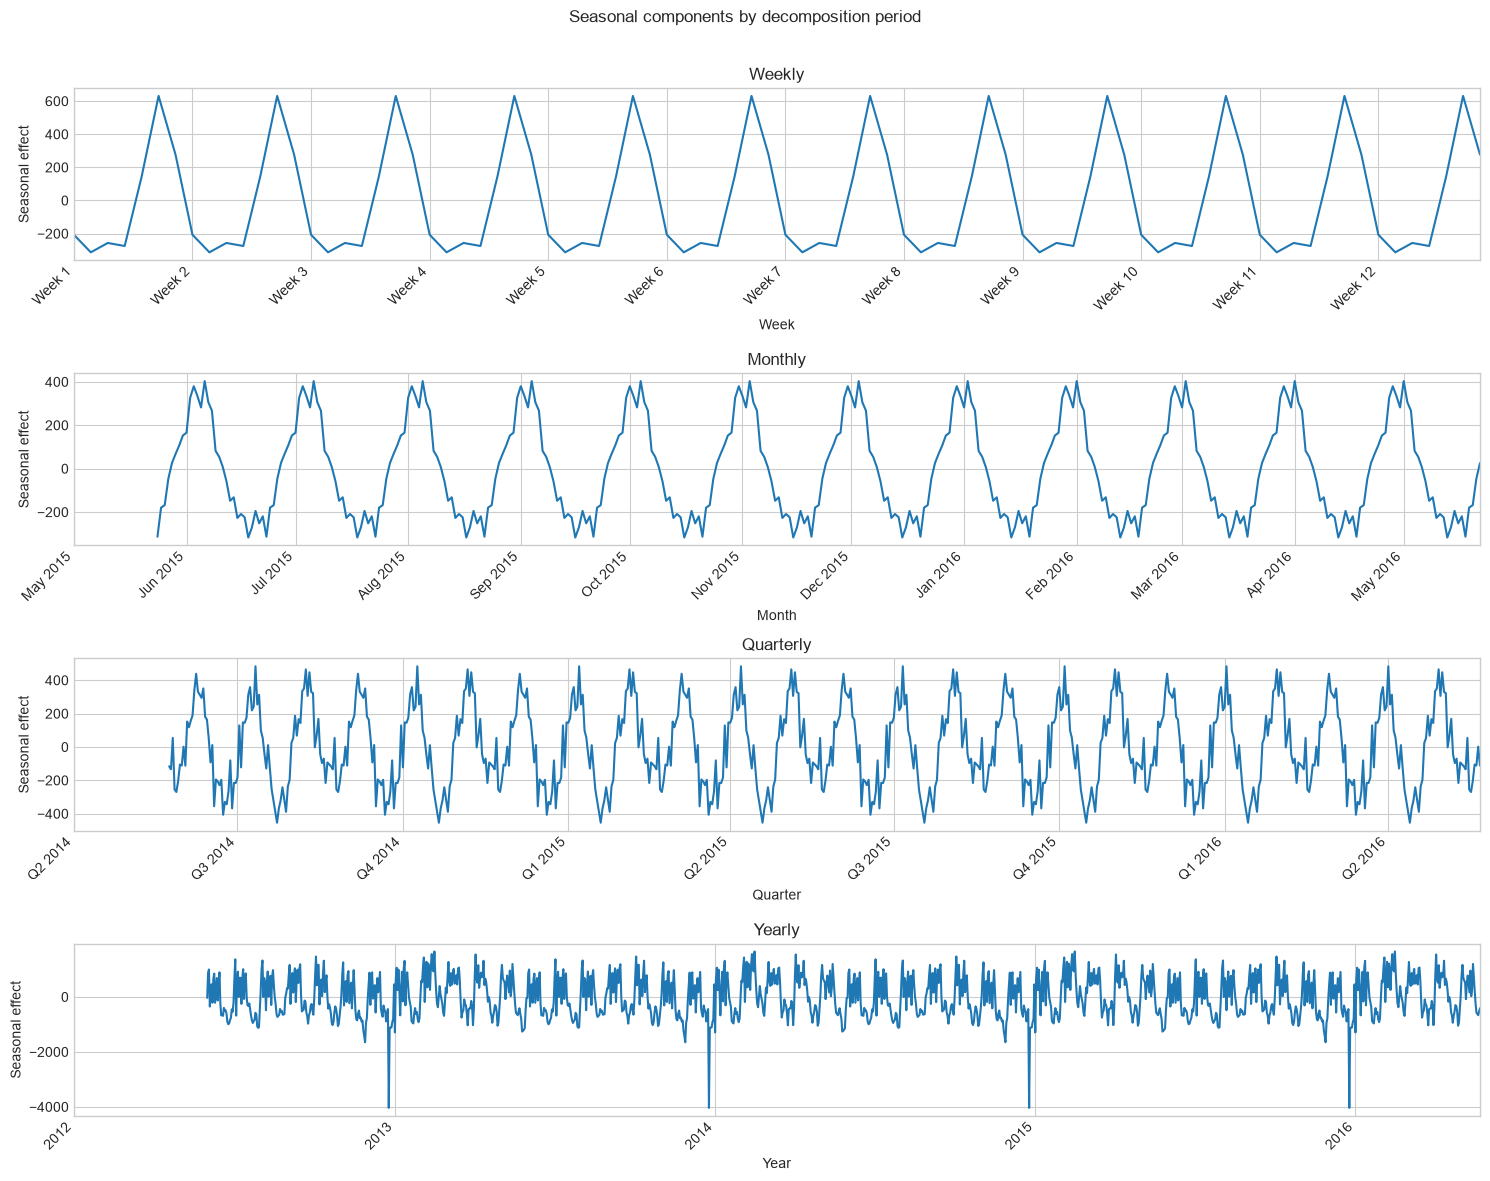

In [32]:
# compare different decomposition periods
decomposition_periods = [7, 30, 90, 365]
decomposition_labels = {
    7: 'weekly',
    30: 'monthly',
    90: 'quarterly',
    365: 'yearly',
}
decomposition_summary = []
seasonal_components = pd.DataFrame(index=series.index)

for period in decomposition_periods:
    decomposition = seasonal_decompose(
        series,
        model='additive',
        period=period,
        extrapolate_trend='period',
    )
    seasonal_components[decomposition_labels[period]] = decomposition.seasonal
    decomposition_summary.append({
        'period': decomposition_labels[period],
        'period_days': period,
        'seasonal_std': decomposition.seasonal.std(),
        'residual_std': decomposition.resid.dropna().std(),
    })

decomposition_summary = pd.DataFrame(decomposition_summary).round(2)
display(decomposition_summary)

display_windows = {
    'weekly': 84,
    'monthly': 365,
    'quarterly': 730,
    'yearly': len(seasonal_components),
}
fig, axes = plt.subplots(
    len(seasonal_components.columns),
    1,
    figsize=(15, 12),
    sharex=False,
)
for axis, column in zip(axes, seasonal_components.columns):
    plot_data = seasonal_components[column].iloc[-display_windows[column]:]
    plot_data.plot(ax=axis)
    axis.set_title(column.title())
    axis.set_ylabel('Seasonal effect')
    if column == 'weekly':
        axis.set_xlabel('Week')
        tick_dates = pd.date_range(
            plot_data.index.min().normalize(),
            plot_data.index.max(),
            freq='W-MON',
        )
        tick_labels = [
            f'Week {index}'
            for index in range(1, len(tick_dates) + 1)
        ]
    elif column == 'monthly':
        axis.set_xlabel('Month')
        start_date = plot_data.index.min().replace(day=1)
        tick_dates = pd.date_range(
            start_date,
            plot_data.index.max(),
            freq='MS',
        )
        tick_labels = [date.strftime('%b %Y') for date in tick_dates]
    elif column == 'quarterly':
        axis.set_xlabel('Quarter')
        start_date = plot_data.index.min().to_period('Q').start_time
        tick_dates = pd.date_range(
            start_date,
            plot_data.index.max(),
            freq='QS',
        )
        tick_labels = [
            f'Q{date.quarter} {date.year}'
            for date in tick_dates
        ]
    else:
        axis.set_xlabel('Year')
        start_date = plot_data.index.min().to_period('Y').start_time
        tick_dates = pd.date_range(
            start_date,
            plot_data.index.max(),
            freq='YS',
        )
        tick_labels = [str(date.year) for date in tick_dates]
    axis.set_xticks(tick_dates)
    axis.set_xticklabels(tick_labels, rotation=45, ha='right')
fig.suptitle('Seasonal components by decomposition period')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


The weekly decomposition has seasonal variation of 284.93 units and residual variation of 434.79 units. The monthly decomposition has seasonal variation of 135.47 units and residual variation of 708.93 units. The quarterly decomposition has seasonal variation of 152.60 units and residual variation of 725.04 units. The yearly decomposition has the largest seasonal variation at 590.51 units and residual variation of 559.85 units. The weekly period is retained as the primary decomposition because the daily series shows weekly dependence. The longer periods are used as validation checks for broader repeating patterns and retail planning windows.


### Inferential time-series analysis

The ADF test evaluates stationarity. The Ljung-Box test evaluates whether autocorrelations up to weekly, monthly, quarterly, and yearly lags are jointly zero.


In [33]:
# run inferential stationarity and autocorrelation tests
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller

adf_results = []
for label, values in {
    'raw sales': series,
    'first difference': series.diff().dropna(),
}.items():
    statistic, p_value, _, _, critical_values, _ = adfuller(
        values,
        autolag='AIC',
    )
    adf_results.append({
        'series': label,
        'adf_statistic': statistic,
        'p_value': p_value,
        'critical_value_5pct': critical_values['5%'],
    })

adf_table = pd.DataFrame(adf_results).round(4)
dependency_lags = {
    'week': 7,
    'month': 30,
    'quarter': 90,
    'year': 365,
}
ljung_box_table = acorr_ljungbox(
    series,
    lags=list(dependency_lags.values()),
    return_df=True,
)[['lb_stat', 'lb_pvalue']]
ljung_box_table.index = pd.Index(dependency_lags, name='period')
ljung_box_table.insert(0, 'lag_days', list(dependency_lags.values()))
ljung_box_table = ljung_box_table.round(4)

display(adf_table)
ljung_box_table


/var/folders/z5/t6prsb910p5cn4_p8358dl280000gq/T/ipykernel_77976/1841885412.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  statistic, p_value, _, _, critical_values, _ = adfuller(
/var/folders/z5/t6prsb910p5cn4_p8358dl280000gq/T/ipykernel_77976/1841885412.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  statistic, p_value, _, _, critical_values, _ = adfuller(


,series,adf_statistic,p_value,critical_value_5pct
0,raw sales,-3.092,0.0272,-2.8636
1,first difference,-15.938,0.0000,-2.8636


,lag_days,lb_stat,lb_pvalue
period,,,
week,7,1924.1378,0.0
month,30,4167.4323,0.0
quarter,90,9628.6833,0.0
year,365,27994.6938,0.0


The raw-series ADF p-value is 0.7662, so the null hypothesis of a unit root is not rejected at the 5% level. The first difference has p-value below 0.001, providing evidence of stationarity after differencing.

The Ljung-Box p-values are 0.0000 at the weekly, monthly, quarterly, and yearly lags. The null hypothesis of no serial dependence is rejected at each scale, so the series is not white noise. These dependencies should be respected in feature engineering and chronological validation.


## Decisions from the exploratory analysis

### Data cleaning and validation decisions

| Action | Evidence from data | Example |
|---|---|---|
| Convert the date field to a datetime representation. | Dates are parseable, unique, sorted, and complete; this creates a reliable time axis. | `2011-01-29` becomes a datetime value. |
| Sort by date and use one datetime index. | The date field defines the complete chronological order; this makes time order explicit for lags, rolling features, and splits. | Order rows from `2011-01-29` to `2011-12-31`. |
| Derive `d` after confirming the chronological date order. | The canonical `d` column is missing; deriving it preserves the required day identifier without trusting a missing field. | Assign sequential day identifiers such as `d_1`, `d_2`, and `d_3`. |
| Fill event-label nulls with `No event`. | Event name and type are missing together on non-event days; filling them distinguishes expected non-events from missing labels. | A non-event row has `event_name = No event`. |
| Keep the zero-sales rows. | The two zero-sales days coincide with Christmas closures; closures may represent genuine demand conditions. | Retain the Christmas row with `sales = 0`. |
| Remove observations before 1 June 2012. | Sales coverage increases sharply from June 2012, indicating a structural regime change. | Keep dates from `2012-06-01` onward. |

### Feature engineering decisions

| Action | Evidence from data | Example |
|---|---|---|
| Derive the `has_event` indicator. | Event labels identify whether a date has an event; this gives models a direct event-presence signal. | `has_event = 1` when `event_name` is not `No event`. |
| Add sales lags at 7, 30, 90, and 365 days. | ACF, PACF, and Ljung-Box tests show dependence at 7, 30, 90, and 365 days; this captures recent and longer-term context. | `sales_lag_7 = sales.shift(7)`. |
| Add 7-day and 28-day rolling means using sales shifted by one day. | Recent sales are serially dependent; shifting sales by one day uses past data only and prevents target leakage. | `sales.shift(1).rolling(7).mean()`. |
| Add sine/cosine encodings for week and month. | Sales show a period of a week and of a month; sine/cosine encodings represent calendar cycles continuously. | Add `week_sin`, `week_cos`, `month_sin`, and `month_cos`. |
| Retain `snap`, `has_event`, `event_name`, and `event_type`. | Event and SNAP values for that day are known before the forecast cutoff; this preserves known demand-related information. | A target day can have `snap = 1` and `has_event = 0`. |
